# COMP5329 Assignment 2


## Section 1：Import libraries And Initialise

This notebook implements the main experimental pipeline for our COMP5329 Assignment 2 project. The goal is to compare CNN models with different depth and width configurations on CIFAR-10, and to evaluate whether architectural choices affect both IID generalization and OOD robustness.

The notebook includes data loading, model definition, parameter counting, IID training, OOD evaluation, result saving, and basic visualization. The generated results are used as experimental evidence for the final research paper.

In [ ]:
import os
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

import torchvision
import torchvision.transforms as transforms

In [ ]:
# set random seed
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [ ]:
EXPERIMENT_TAG = "e50"
RESULTS_DIR = f"results_{EXPERIMENT_TAG}"
CHECKPOINT_DIR = f"checkpoints_{EXPERIMENT_TAG}"

os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

print("Saving results to:", RESULTS_DIR)
print("Saving checkpoints to:", CHECKPOINT_DIR)

Saving results to: results_e50
Saving checkpoints to: checkpoints_e50


## Section 2: Load Dataset
We use CIFAR-10 as the benchmark dataset because it is a standard image classification dataset with 10 classes and 32×32 RGB images. The training set is used to train the CNN models, while the test set is used to evaluate IID generalization performance.

For training, random crop and random horizontal flip are applied as data augmentation. These transformations help reduce overfitting and improve the models' ability to generalize to small spatial variations.

In [ ]:
# Chose Dataset : CIFAR-10
train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.4914, 0.4822, 0.4465),
        std=(0.2470, 0.2435, 0.2616)
    )
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.4914, 0.4822, 0.4465),
        std=(0.2470, 0.2435, 0.2616)
    )
])

train_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=train_transform
)

test_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=test_transform
)

batch_size = 128

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2
)

## Section 3: Build CNN Model
We define a plain CNN family with three stages. Each block contains one 3×3 convolution, batch normalization, and ReLU activation. The first block of Stage 2 and Stage 3 uses stride 2 for downsampling. All models share the same block type and classifier head, so the main architectural difference comes from depth and width.
The main research question in this notebook is whether increasing model depth or width leads to better robustness under distribution shift. To make the comparison fair, all models use the same basic convolutional block and classifier head. The key difference is the number of blocks and channels in each stage.

### Section 3.1： Defined CNN Model
Each CNN is built from repeated convolutional blocks. A block contains a convolution layer, batch normalization, and ReLU activation. Batch normalization is included to stabilize training, while ReLU introduces non-linearity.

Downsampling is performed at the beginning of later stages using stride 2. This reduces the spatial resolution and allows the model to learn higher-level features.

In [ ]:
class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()

        self.block = nn.Sequential(
            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=3,
                stride=stride,
                padding=1,
                bias=False
            ),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.block(x)


class PlainCNN(nn.Module):
    def __init__(self, blocks_per_stage, channels_per_stage, num_classes=10):
        super().__init__()

        self.blocks_per_stage = blocks_per_stage
        self.channels_per_stage = channels_per_stage

        layers = []
        in_channels = 3

        for stage_idx, (num_blocks, out_channels) in enumerate(
            zip(blocks_per_stage, channels_per_stage)
        ):
            for block_idx in range(num_blocks):
                if stage_idx > 0 and block_idx == 0:
                    stride = 2
                else:
                    stride = 1

                layers.append(
                    ConvBlock(
                        in_channels=in_channels,
                        out_channels=out_channels,
                        stride=stride
                    )
                )

                in_channels = out_channels

        self.features = nn.Sequential(*layers)
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Linear(channels_per_stage[-1], num_classes)

    def forward(self, x, return_features=False):
        x = self.features(x)
        x = self.pool(x)
        features = torch.flatten(x, 1)
        logits = self.classifier(features)

        if return_features:
            return logits, features

        return logits

### Model Configurations

The model configurations are designed to compare different architectural trade-offs:

- **CNN-SW** represents a shallow-wide model.
- **CNN-DN** represents a deeper-narrower model.
- **CNN-Balanced** represents a more balanced architecture.

This allows us to examine whether robustness is mainly affected by depth, width, or a balance between the two.

In [ ]:
model_configs = {
    "CNN-SW": {
        "blocks_per_stage": [2, 2, 2],
        "channels_per_stage": [64, 128, 256],
        "type": "shallow-wide"
    },
    "CNN-M": {
        "blocks_per_stage": [4, 4, 4],
        "channels_per_stage": [40, 80, 160],
        "type": "medium"
    },
    "CNN-DN": {
        "blocks_per_stage": [5, 5, 5],
        "channels_per_stage": [36, 72, 144],
        "type": "deep-narrow"
    }
}

### Section 3.2：Count parameters and Record

In [ ]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


model_summary = []

for model_name, cfg in model_configs.items():
    model = PlainCNN(
        blocks_per_stage=cfg["blocks_per_stage"],
        channels_per_stage=cfg["channels_per_stage"]
    )

    params = count_parameters(model)

    model_summary.append({
        "model": model_name,
        "blocks_per_stage": str(cfg["blocks_per_stage"]),
        "channels_per_stage": str(cfg["channels_per_stage"]),
        "conv_layers": sum(cfg["blocks_per_stage"]),
        "type": cfg["type"],
        "parameters": params,
        "parameters_M": params / 1e6
    })

model_summary_df = pd.DataFrame(model_summary)
model_summary_df

,model,blocks_per_stage,channels_per_stage,conv_layers,type,parameters,parameters_M
0,CNN-SW,"[2, 2, 2]","[64, 128, 256]",6,shallow-wide,1148874,1.148874
1,CNN-M,"[4, 4, 4]","[40, 80, 160]",12,medium,1056130,1.056130
2,CNN-DN,"[5, 5, 5]","[36, 72, 144]",15,deep-narrow,1101358,1.101358


The parameter count is recorded to ensure that the models are compared fairly. Since depth and width can both increase model capacity, reporting the number of trainable parameters helps interpret whether performance differences are caused by architectural design or simply by having more parameters.

In [ ]:
model_summary_df.to_csv(f"{RESULTS_DIR}/model_summary.csv", index=False)

In [ ]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    total_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)

        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total += labels.size(0)

    avg_loss = total_loss / total
    accuracy = correct / total

    return avg_loss, accuracy


def evaluate(model, loader, criterion, device):
    model.eval()

    total_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * images.size(0)

            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)

    avg_loss = total_loss / total
    accuracy = correct / total

    return avg_loss, accuracy

### Section 3.3: IID Training on CIFAR-10

All models are trained on CIFAR-10 using the same optimizer, learning rate schedule, batch size, number of epochs, and data augmentation. No model-specific hyperparameter tuning is applied.
Using the same training settings for all models ensures that the comparison focuses on architecture rather than training tricks. The same number of epochs, optimizer, learning rate schedule, batch size, and data augmentation are used across all models.

In [ ]:
num_epochs = 50

all_logs = []

for model_name, cfg in model_configs.items():
    print("=" * 60)
    print("Training model:", model_name)
    print("=" * 60)

    set_seed(42)

    model = PlainCNN(
        blocks_per_stage=cfg["blocks_per_stage"],
        channels_per_stage=cfg["channels_per_stage"]
    ).to(device)

    criterion = nn.CrossEntropyLoss()

    optimizer = optim.SGD(
        model.parameters(),
        lr=0.1,
        momentum=0.9,
        weight_decay=5e-4
    )

    scheduler = optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=num_epochs
    )

    best_test_acc = 0.0
    start_time = time.time()

    for epoch in range(1, num_epochs + 1):
        train_loss, train_acc = train_one_epoch(
            model,
            train_loader,
            criterion,
            optimizer,
            device
        )

        test_loss, test_acc = evaluate(
            model,
            test_loader,
            criterion,
            device
        )

        scheduler.step()

        if test_acc > best_test_acc:
            best_test_acc = test_acc
            torch.save(
                model.state_dict(),
                f"{CHECKPOINT_DIR}/{model_name}_best.pth"
            )

        log_row = {
            "model": model_name,
            "epoch": epoch,
            "train_loss": train_loss,
            "train_acc": train_acc,
            "test_loss": test_loss,
            "test_acc": test_acc,
            "best_test_acc": best_test_acc,
            "lr": scheduler.get_last_lr()[0]
        }

        all_logs.append(log_row)

        print(
            f"Epoch [{epoch:03d}/{num_epochs}] "
            f"Train Loss: {train_loss:.4f} "
            f"Train Acc: {train_acc:.4f} "
            f"Test Loss: {test_loss:.4f} "
            f"Test Acc: {test_acc:.4f} "
            f"Best: {best_test_acc:.4f}"
        )

    total_time = time.time() - start_time
    print(f"{model_name} training time: {total_time:.2f} seconds")

logs_df = pd.DataFrame(all_logs)
logs_df.to_csv(f"{RESULTS_DIR}/training_logs.csv", index=False)

Training model: CNN-SW
Epoch [001/50] Train Loss: 1.5302 Train Acc: 0.4283 Test Loss: 1.3892 Test Acc: 0.5299 Best: 0.5299
Epoch [002/50] Train Loss: 1.0797 Train Acc: 0.6129 Test Loss: 1.4437 Test Acc: 0.5328 Best: 0.5328
Epoch [003/50] Train Loss: 0.8902 Train Acc: 0.6830 Test Loss: 1.1110 Test Acc: 0.6171 Best: 0.6171
Epoch [004/50] Train Loss: 0.7820 Train Acc: 0.7255 Test Loss: 1.7491 Test Acc: 0.5063 Best: 0.6171
Epoch [005/50] Train Loss: 0.6983 Train Acc: 0.7578 Test Loss: 0.8154 Test Acc: 0.7247 Best: 0.7247
Epoch [006/50] Train Loss: 0.6470 Train Acc: 0.7759 Test Loss: 0.7983 Test Acc: 0.7277 Best: 0.7277
Epoch [007/50] Train Loss: 0.6089 Train Acc: 0.7894 Test Loss: 0.8604 Test Acc: 0.7354 Best: 0.7354
Epoch [008/50] Train Loss: 0.5766 Train Acc: 0.8009 Test Loss: 0.7822 Test Acc: 0.7393 Best: 0.7393
Epoch [009/50] Train Loss: 0.5579 Train Acc: 0.8082 Test Loss: 0.7576 Test Acc: 0.7428 Best: 0.7428
Epoch [010/50] Train Loss: 0.5295 Train Acc: 0.8207 Test Loss: 0.7984 Test Ac

## Section 4: IID Generalization Results

This section reports the standard test accuracy of each model on the original CIFAR-10 test set. This evaluation measures IID generalization, where the training and test data follow the same distribution.

The IID results provide a baseline for later OOD evaluation. A model with high IID accuracy is not necessarily more robust under distribution shift, so both IID and OOD results need to be compared.

In [ ]:
final_iid_results = []

for model_name in model_configs.keys():
    model_logs = logs_df[logs_df["model"] == model_name]

    final_row = model_logs.iloc[-1]
    best_row = model_logs.loc[model_logs["test_acc"].idxmax()]

    final_iid_results.append({
        "model": model_name,
        "final_train_acc": final_row["train_acc"],
        "final_test_acc": final_row["test_acc"],
        "best_test_acc": best_row["test_acc"],
        "best_epoch": int(best_row["epoch"]),
        "generalization_gap": final_row["train_acc"] - final_row["test_acc"]
    })

final_iid_results_df = pd.DataFrame(final_iid_results)
final_iid_results_df.to_csv(f"{RESULTS_DIR}/final_iid_results.csv", index=False)

final_iid_results_df

,model,final_train_acc,final_test_acc,best_test_acc,best_epoch,generalization_gap
0,CNN-SW,0.98166,0.9146,0.9151,49,0.06706
1,CNN-M,0.99456,0.9283,0.9285,46,0.06626
2,CNN-DN,0.99176,0.9269,0.9269,50,0.06486


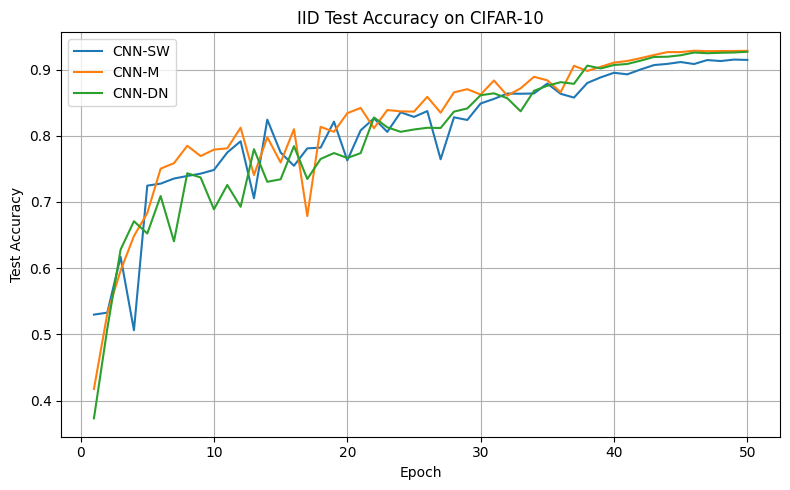

In [ ]:
plt.figure(figsize=(8, 5))

for model_name in model_configs.keys():
    model_logs = logs_df[logs_df["model"] == model_name]
    plt.plot(
        model_logs["epoch"],
        model_logs["test_acc"],
        label=model_name
    )

plt.xlabel("Epoch")
plt.ylabel("Test Accuracy")
plt.title("IID Test Accuracy on CIFAR-10")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/iid_test_accuracy_curve.png", dpi=300)
plt.show()

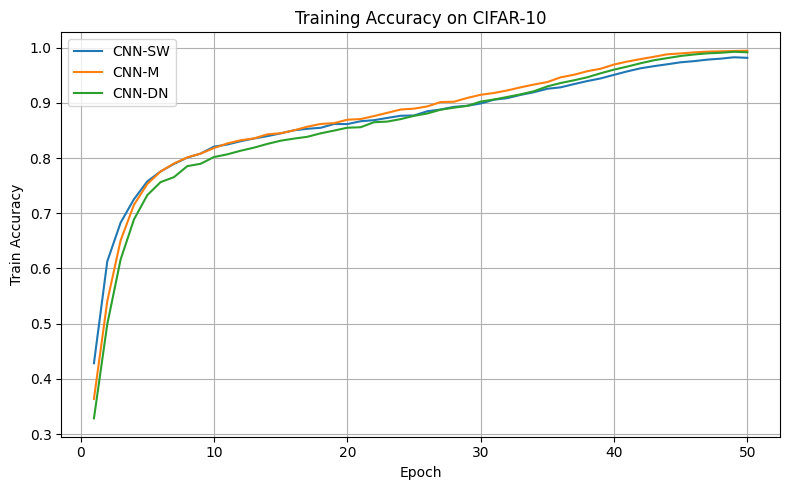

In [ ]:
plt.figure(figsize=(8, 5))

for model_name in model_configs.keys():
    model_logs = logs_df[logs_df["model"] == model_name]
    plt.plot(
        model_logs["epoch"],
        model_logs["train_acc"],
        label=model_name
    )

plt.xlabel("Epoch")
plt.ylabel("Train Accuracy")
plt.title("Training Accuracy on CIFAR-10")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/train_accuracy_curve.png", dpi=300)
plt.show()

## Section 5: Experiment

### Section 5.1: OOD Experiment
In this section, we evaluate the trained models under several distribution shifts. The purpose is to test whether the models remain reliable when the test images are corrupted or visually changed.

The OOD settings include Gaussian noise, Gaussian blur, brightness shift, and contrast shift. These transformations simulate common image corruptions and allow us to compare robustness across different CNN architectures.

In [ ]:
# OOD transforms for CIFAR-10
ood_transforms = {
    "gaussian_noise": transforms.Compose([
        transforms.ToTensor(),
        transforms.Lambda(lambda x: torch.clamp(x + 0.1 * torch.randn_like(x), 0, 1)),
        transforms.Normalize(
            mean=(0.4914, 0.4822, 0.4465),
            std=(0.2470, 0.2435, 0.2616)
        )
    ]),

    "blur": transforms.Compose([
        transforms.GaussianBlur(kernel_size=3, sigma=1.0),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=(0.4914, 0.4822, 0.4465),
            std=(0.2470, 0.2435, 0.2616)
        )
    ]),

    "brightness_shift": transforms.Compose([
        transforms.ColorJitter(brightness=0.4),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=(0.4914, 0.4822, 0.4465),
            std=(0.2470, 0.2435, 0.2616)
        )
    ]),

    "contrast_shift": transforms.Compose([
        transforms.ColorJitter(contrast=0.4),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=(0.4914, 0.4822, 0.4465),
            std=(0.2470, 0.2435, 0.2616)
        )
    ])
}

In [ ]:
ood_loaders = {}

for shift_name, shift_transform in ood_transforms.items():
    ood_dataset = torchvision.datasets.CIFAR10(
        root="./data",
        train=False,
        download=True,
        transform=shift_transform
    )

    ood_loader = DataLoader(
        ood_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0
    )

    ood_loaders[shift_name] = ood_loader

print("OOD loaders created:", list(ood_loaders.keys()))

OOD loaders created: ['gaussian_noise', 'blur', 'brightness_shift', 'contrast_shift']


In [ ]:
criterion = nn.CrossEntropyLoss()

ood_results = []

for model_name, cfg in model_configs.items():
    print("=" * 60)
    print("OOD testing model:", model_name)
    print("=" * 60)

    model = PlainCNN(
        blocks_per_stage=cfg["blocks_per_stage"],
        channels_per_stage=cfg["channels_per_stage"]
    ).to(device)

    checkpoint_path = f"{CHECKPOINT_DIR}/{model_name}_best.pth"
    model.load_state_dict(torch.load(checkpoint_path, map_location=device))

    # Get IID best accuracy from final_iid_results_df
    iid_best_acc = final_iid_results_df.loc[
        final_iid_results_df["model"] == model_name,
        "best_test_acc"
    ].values[0]

    for shift_name, ood_loader in ood_loaders.items():
        ood_loss, ood_acc = evaluate(
            model,
            ood_loader,
            criterion,
            device
        )

        ood_drop = iid_best_acc - ood_acc

        ood_results.append({
            "model": model_name,
            "ood_shift": shift_name,
            "iid_best_acc": iid_best_acc,
            "ood_loss": ood_loss,
            "ood_acc": ood_acc,
            "ood_drop": ood_drop
        })

        print(
            f"{model_name} | {shift_name} | "
            f"OOD Acc: {ood_acc:.4f} | "
            f"Drop: {ood_drop:.4f}"
        )

ood_results_df = pd.DataFrame(ood_results)
ood_results_df.to_csv(f"{RESULTS_DIR}/ood_results.csv", index=False)

ood_results_df

OOD testing model: CNN-SW
CNN-SW | gaussian_noise | OOD Acc: 0.2111 | Drop: 0.7040
CNN-SW | blur | OOD Acc: 0.4712 | Drop: 0.4439
CNN-SW | brightness_shift | OOD Acc: 0.9024 | Drop: 0.0127
CNN-SW | contrast_shift | OOD Acc: 0.9008 | Drop: 0.0143
OOD testing model: CNN-M
CNN-M | gaussian_noise | OOD Acc: 0.2671 | Drop: 0.6614
CNN-M | blur | OOD Acc: 0.5155 | Drop: 0.4130
CNN-M | brightness_shift | OOD Acc: 0.9222 | Drop: 0.0063
CNN-M | contrast_shift | OOD Acc: 0.9232 | Drop: 0.0053
OOD testing model: CNN-DN
CNN-DN | gaussian_noise | OOD Acc: 0.2682 | Drop: 0.6587
CNN-DN | blur | OOD Acc: 0.5281 | Drop: 0.3988
CNN-DN | brightness_shift | OOD Acc: 0.9212 | Drop: 0.0057
CNN-DN | contrast_shift | OOD Acc: 0.9226 | Drop: 0.0043


,model,ood_shift,iid_best_acc,ood_loss,ood_acc,ood_drop
0,CNN-SW,gaussian_noise,0.9151,5.843105,0.2111,0.7040
1,CNN-SW,blur,0.9151,2.090575,0.4712,0.4439
2,CNN-SW,brightness_shift,0.9151,0.305212,0.9024,0.0127
3,CNN-SW,contrast_shift,0.9151,0.307334,0.9008,0.0143
4,CNN-M,gaussian_noise,0.9285,4.445519,0.2671,0.6614
5,CNN-M,blur,0.9285,2.230304,0.5155,0.4130
6,CNN-M,brightness_shift,0.9285,0.257288,0.9222,0.0063
7,CNN-M,contrast_shift,0.9285,0.257269,0.9232,0.0053
8,CNN-DN,gaussian_noise,0.9269,4.311892,0.2682,0.6587
9,CNN-DN,blur,0.9269,2.063570,0.5281,0.3988


In [ ]:
ood_summary_df = (
    ood_results_df
    .groupby("model")
    .agg(
        mean_ood_acc=("ood_acc", "mean"),
        mean_ood_drop=("ood_drop", "mean")
    )
    .reset_index()
)

ood_summary_df = ood_summary_df.merge(
    final_iid_results_df[["model", "best_test_acc", "generalization_gap"]],
    on="model",
    how="left"
)

ood_summary_df.to_csv(f"{RESULTS_DIR}/ood_summary.csv", index=False)

ood_summary_df

,model,mean_ood_acc,mean_ood_drop,best_test_acc,generalization_gap
0,CNN-DN,0.660025,0.266875,0.9269,0.06486
1,CNN-M,0.657000,0.271500,0.9285,0.06626
2,CNN-SW,0.621375,0.293725,0.9151,0.06706


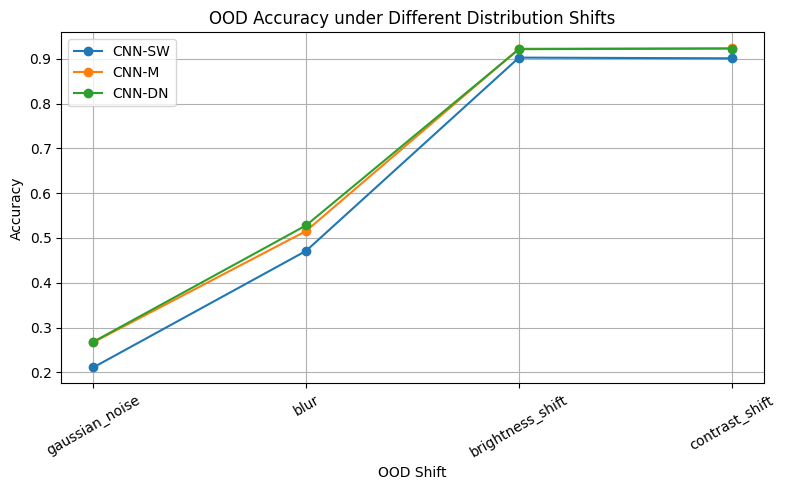

In [ ]:
plt.figure(figsize=(8, 5))

for model_name in model_configs.keys():
    model_ood = ood_results_df[ood_results_df["model"] == model_name]

    plt.plot(
        model_ood["ood_shift"],
        model_ood["ood_acc"],
        marker="o",
        label=model_name
    )

plt.xlabel("OOD Shift")
plt.ylabel("Accuracy")
plt.title("OOD Accuracy under Different Distribution Shifts")
plt.legend()
plt.grid(True)
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/ood_accuracy.png", dpi=300)
plt.show()

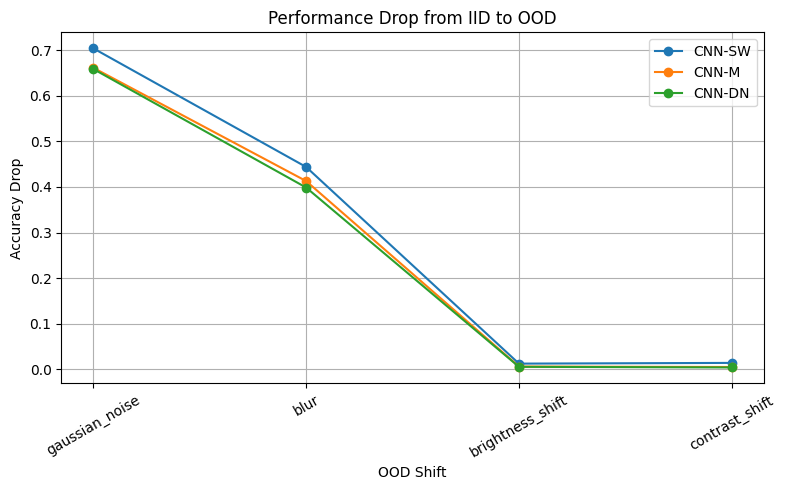

In [ ]:
plt.figure(figsize=(8, 5))

for model_name in model_configs.keys():
    model_ood = ood_results_df[ood_results_df["model"] == model_name]

    plt.plot(
        model_ood["ood_shift"],
        model_ood["ood_drop"],
        marker="o",
        label=model_name
    )

plt.xlabel("OOD Shift")
plt.ylabel("Accuracy Drop")
plt.title("Performance Drop from IID to OOD")
plt.legend()
plt.grid(True)
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/ood_drop.png", dpi=300)
plt.show()

## Conclusion

This notebook implements the candidate CNN models, trains them on CIFAR-10, evaluates IID generalization performance, and tests OOD robustness under Gaussian noise, Gaussian blur, brightness shift, and contrast shift.

The outputs of this 50-epoch run are saved into the `results_e50/` folder and the best model checkpoints are saved into the `checkpoints_e50/` folder. These files can be used by Member B for representation analysis and visualization without overwriting the original 10-epoch pilot outputs.

The following files are prepared for further analysis:

- `results_e50/model_summary.csv`: parameter count and model configuration summary
- `results_e50/training_logs.csv`: epoch-level training and test logs
- `results_e50/final_iid_results.csv`: final IID generalization results
- `results_e50/ood_results.csv`: raw OOD evaluation results for each model and shift
- `results_e50/ood_summary.csv`: mean OOD accuracy and mean OOD drop for each model
- `checkpoints_e50/`: best model checkpoints for feature extraction and effective dimensionality analysis

Member B can use these outputs to compute representation complexity, effective dimensionality proxy, robustness drop, and visualization figures.